# Snap-to-Sell — Live Pipeline Demo

Photograph of a packaged corner-store product → **recognise → retrieve price/image →
generate a grounded listing → verify a same-SKU image swap → guardrails → human review →
publish**.

This notebook runs the pipeline **stage by stage** (good for presenting), then end-to-end.
It runs **with no API key** using offline fallbacks; set `GEMINI_API_KEY` (or `OPENAI_API_KEY`)
before launching Jupyter to see real recognition + generation.

In [1]:
import os, sys, json
from pathlib import Path
from dataclasses import asdict

# Run from the repo root (snap-to-sell/) so imports and data paths resolve.
if Path.cwd().name == "notebooks":
    os.chdir("..")
sys.path.insert(0, str(Path.cwd()))
%matplotlib inline

print("cwd:", Path.cwd(), "— set your provider/key in the Configuration cell below")

cwd: /sessions/eager-lucid-gates/mnt/Project/MIA5100_group_project/snap-to-sell — set your provider/key in the Configuration cell below


## Configuration

Set your provider, model, key, and strict-mode here, then run the rest of the notebook. Leave
`OPENAI_API_KEY` blank to be prompted (masked) or to stay in offline mode. Re-run this cell to
change any setting.

In [2]:
import os, getpass

# Blank = use whatever is in your .env (recommended). Fill a field ONLY to override .env for this run.
SNAP_LLM_PROVIDER     = ""    # "openai" | "anthropic" | "gemini" | ""  -> blank uses .env / auto-detect
SNAP_OPENAI_MODEL     = ""    # e.g. "gpt-4o-mini"; blank -> .env / default
SNAP_RETRIEVE_BACKEND = ""    # "off" (Open Food Facts) | "shopping" (Serper); blank -> .env
OPENAI_API_KEY        = ""    # paste to override .env; blank -> use .env
SERPER_API_KEY        = ""    # blank -> use .env  (needed for backend="shopping")
SNAP_STRICT_PROVIDER  = None  # True / False to override; None -> use .env

# --- only non-empty cell values override .env ---
for _k, _v in {
    "SNAP_LLM_PROVIDER": SNAP_LLM_PROVIDER,
    "SNAP_OPENAI_MODEL": SNAP_OPENAI_MODEL,
    "SNAP_RETRIEVE_BACKEND": SNAP_RETRIEVE_BACKEND,
    "OPENAI_API_KEY": OPENAI_API_KEY,
    "SERPER_API_KEY": SERPER_API_KEY,
}.items():
    if _v:
        os.environ[_k] = _v
if SNAP_STRICT_PROVIDER is not None:
    os.environ["SNAP_STRICT_PROVIDER"] = "1" if SNAP_STRICT_PROVIDER else ""

# config auto-loads the nearest .env (override=False), so keys in .env are picked up here.
from src.snap_to_sell import config
config.refresh()

# Prompt for a key ONLY if the chosen provider is OpenAI and no key came from the cell or .env.
_provider = (os.environ.get("SNAP_LLM_PROVIDER") or config.LLM_PROVIDER or "").lower()
if _provider == "openai" and not config.OPENAI_API_KEY:
    try:
        _k = getpass.getpass("OPENAI_API_KEY (blank = offline): ")
    except Exception:
        _k = ""
    if _k:
        os.environ["OPENAI_API_KEY"] = _k
        config.refresh()

# Convenience: with the shopping backend, show the clean retailer image (unless you set SNAP_IMAGE_MODE).
if config.RETRIEVE_BACKEND == "shopping" and not os.environ.get("SNAP_IMAGE_MODE"):
    os.environ["SNAP_IMAGE_MODE"] = "swap"
    config.refresh()

print("retrieval:", config.RETRIEVE_BACKEND)
print("provider :", config.active_provider() or "offline (no key)")
print("model    :", config.OPENAI_MODEL)
print("strict   :", config.STRICT_PROVIDER)

retrieval: off
provider : offline (no key)
model    : gpt-4o-mini
strict   : False


## 1. The input photo
A real phone photo of a corner-store product (Duracell AA 24-pack).

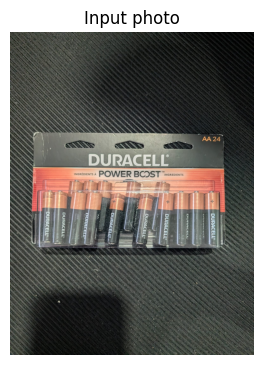

In [3]:
import matplotlib.pyplot as plt
from PIL import Image

SAMPLE = "data/testset/duracell_aa.jpg"
plt.figure(figsize=(3.2, 4.2))
plt.imshow(Image.open(SAMPLE)); plt.axis("off"); plt.title("Input photo"); plt.show()

## 2. Stage by stage

Each stage is a plain function behind a frozen interface. We call them one at a time and
inspect the structured object each returns.

In [4]:
from src.snap_to_sell.capture import preprocess
from src.snap_to_sell.recognise import recognise
from src.snap_to_sell.retrieve import retrieve
from src.snap_to_sell.generate import generate
from src.snap_to_sell.imagematch import choose_image
from src.snap_to_sell.guardrails import apply

# 1) Capture / pre-process (OpenCV)
clean = preprocess(SAMPLE)
print("1. Capture ->", clean)

1. Capture -> data/testset/duracell_aa.norm.jpg


In [5]:
# 2) Recognise (hosted VLM+OCR, or offline sidecar)
identity = recognise(clean)
print(json.dumps(asdict(identity), indent=2))

{
  "brand": "Duracell",
  "product": "AA Batteries",
  "variant": "Power Boost",
  "size": "24 pack",
  "category": "household",
  "ocr_text": "DURACELL POWER BOOST AA 24",
  "barcode": null,
  "confidence": 0.9,
  "search_query": "Duracell AA Batteries 24 pack",
  "catalogue_image_url": "data/testset/duracell_catalogue.jpg"
}


In [6]:
# 3) Retrieve (Open Food Facts + Open Prices, or offline bundle)
bundle = retrieve(identity)
print(json.dumps(asdict(bundle), indent=2, default=str))

{
  "canonical_name": "Duracell AA Batteries Power Boost 24 pack",
  "category_tags": [
    "household"
  ],
  "price": {
    "currency": "CAD",
    "point": null,
    "low": null,
    "high": null,
    "basis": "offline: no retrieval"
  },
  "images": [
    {
      "url": "data/testset/duracell_catalogue.jpg",
      "licence": "(demo)",
      "source": "sidecar",
      "match_score": 0.0
    }
  ],
  "ambiguous": false
}


[retrieve] OFF search failed ('Duracell AA Batteries 24 pack'): HTTPSConnectionPool(host='search.openfoodfacts.org', port=443): Max retries exceeded with url: /search?q=Duracell+AA+Batteries+24+pack&page_size=5&fields=code%2Cproduct_name%2Cgeneric_name%2Cbrands%2Ccategories_tags%2Cimage_front_url%2Cimage_url%2Cquantity (Caused by ProxyError('Unable to connect to proxy', OSError('Tunnel connection failed: 403 Forbidden')))
[retrieve] OPF search unavailable: HTTPSConnectionPool(host='world.openproductsfacts.org', port=443): Max retries exceeded with url: /cgi/search.pl?search_terms=Duracell+AA+Batteries+24+pack&search_simple=1&action=process&json=1&page_size=5 (Caused by ProxyError('Unable to connect to proxy', OSError('Tunnel connection failed: 403 Forbidden')))
[retrieve] no catalogue hit; using offline bundle


In [7]:
# 4) Generate (grounded LLM, or deterministic template)
draft = generate(identity, bundle)
print("TITLE      :", draft.title)
print("DESCRIPTION:", draft.description)
print("PRICE      :", draft.price.point, draft.price.currency, "|", draft.price.basis)

TITLE      : Duracell AA Batteries Power Boost 24 pack
DESCRIPTION: Duracell AA Batteries Power Boost 24 pack. 24 pack household.
PRICE      : None CAD | offline: no retrieval


In [8]:
# 5) Image upgrade — adopt a catalogue image only if it confidently matches the same SKU
img_ref, swapped = choose_image(clean, bundle)
draft.image_url = img_ref
draft.flags.image_swapped = swapped
print("image swapped:", swapped)
print("image used   :", img_ref)

image swapped: False
image used   : data/testset/duracell_aa.norm.jpg


In [9]:
# 6) Guardrails — age-restriction, confidence, claim-grounding
validated = apply(draft, identity, bundle)
print("compliance:", validated.compliance_status)
print("flags     :", json.dumps(asdict(validated.listing.flags), indent=2))

compliance: clear
flags     : {
  "age_restricted": false,
  "low_confidence": false,
  "unverifiable_claims": [],
  "image_swapped": false,
  "image_enhanced": false,
  "retrieval_ambiguous": false
}


## 3. The whole thing in one call
`pipeline.run()` chains all six stages.

In [10]:
from src.snap_to_sell.pipeline import run
result = run(SAMPLE)
print(json.dumps(asdict(result), indent=2, default=str))

{
  "listing": {
    "identity": {
      "brand": "Duracell",
      "product": "AA Batteries",
      "variant": "Power Boost",
      "size": "24 pack",
      "category": "household",
      "ocr_text": "DURACELL POWER BOOST AA 24",
      "barcode": null,
      "confidence": 0.9,
      "search_query": "Duracell AA Batteries 24 pack",
      "catalogue_image_url": "data/testset/duracell_catalogue.jpg"
    },
    "title": "Duracell AA Batteries Power Boost 24 pack",
    "description": "Duracell AA Batteries Power Boost 24 pack. 24 pack household.",
    "price": {
      "currency": "CAD",
      "point": null,
      "low": null,
      "high": null,
      "basis": "offline: no retrieval"
    },
    "image_url": "data/testset/duracell_aa.norm.jpg",
    "flags": {
      "age_restricted": false,
      "low_confidence": false,
      "unverifiable_claims": [],
      "image_swapped": false,
      "image_enhanced": false,
      "retrieval_ambiguous": false
    }
  },
  "compliance_status": "clear",
 

[retrieve] OFF search failed ('Duracell AA Batteries 24 pack'): HTTPSConnectionPool(host='search.openfoodfacts.org', port=443): Max retries exceeded with url: /search?q=Duracell+AA+Batteries+24+pack&page_size=5&fields=code%2Cproduct_name%2Cgeneric_name%2Cbrands%2Ccategories_tags%2Cimage_front_url%2Cimage_url%2Cquantity (Caused by ProxyError('Unable to connect to proxy', OSError('Tunnel connection failed: 403 Forbidden')))
[retrieve] OPF search unavailable: HTTPSConnectionPool(host='world.openproductsfacts.org', port=443): Max retries exceeded with url: /cgi/search.pl?search_terms=Duracell+AA+Batteries+24+pack&search_simple=1&action=process&json=1&page_size=5 (Caused by ProxyError('Unable to connect to proxy', OSError('Tunnel connection failed: 403 Forbidden')))
[retrieve] no catalogue hit; using offline bundle


## 4. Responsible-AI check: age-restricted products

The same pipeline on two real tobacco packs — including a **Chinese-language** pack, which tests
multilingual recognition. Both are flagged and routed to review instead of auto-publishing.

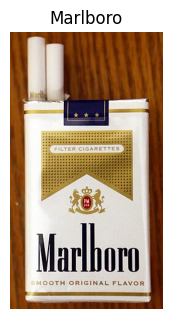

Marlboro: compliance=flagged | age_restricted=True
  title: Marlboro Cigarettes Smooth Original Flavor 20 pack



[retrieve] OFF search failed ('Marlboro Cigarettes 20 pack'): HTTPSConnectionPool(host='search.openfoodfacts.org', port=443): Max retries exceeded with url: /search?q=Marlboro+Cigarettes+20+pack&page_size=5&fields=code%2Cproduct_name%2Cgeneric_name%2Cbrands%2Ccategories_tags%2Cimage_front_url%2Cimage_url%2Cquantity (Caused by ProxyError('Unable to connect to proxy', OSError('Tunnel connection failed: 403 Forbidden')))
[retrieve] OPF search unavailable: HTTPSConnectionPool(host='world.openproductsfacts.org', port=443): Max retries exceeded with url: /cgi/search.pl?search_terms=Marlboro+Cigarettes+20+pack&search_simple=1&action=process&json=1&page_size=5 (Caused by ProxyError('Unable to connect to proxy', OSError('Tunnel connection failed: 403 Forbidden')))
[retrieve] no catalogue hit; using offline bundle


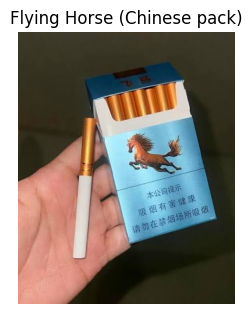

Flying Horse (Chinese pack): compliance=flagged | age_restricted=True
  title: Flying Horse (飞马) Cigarettes 20 pack



[retrieve] OFF search failed ('Flying Horse (飞马) Cigarettes 20 pack'): HTTPSConnectionPool(host='search.openfoodfacts.org', port=443): Max retries exceeded with url: /search?q=Flying+Horse+%28%E9%A3%9E%E9%A9%AC%29+Cigarettes+20+pack&page_size=5&fields=code%2Cproduct_name%2Cgeneric_name%2Cbrands%2Ccategories_tags%2Cimage_front_url%2Cimage_url%2Cquantity (Caused by ProxyError('Unable to connect to proxy', OSError('Tunnel connection failed: 403 Forbidden')))
[retrieve] OPF search unavailable: HTTPSConnectionPool(host='world.openproductsfacts.org', port=443): Max retries exceeded with url: /cgi/search.pl?search_terms=Flying+Horse+%28%E9%A3%9E%E9%A9%AC%29+Cigarettes+20+pack&search_simple=1&action=process&json=1&page_size=5 (Caused by ProxyError('Unable to connect to proxy', OSError('Tunnel connection failed: 403 Forbidden')))
[retrieve] no catalogue hit; using offline bundle


In [11]:
for name, path in [("Marlboro", "data/testset/marlboro.jpg"),
                   ("Flying Horse (Chinese pack)", "data/testset/flyinghorse.jpg")]:
    plt.figure(figsize=(2.8, 3.6))
    plt.imshow(Image.open(path)); plt.axis("off"); plt.title(name); plt.show()
    v = run(path)
    print(f"{name}: compliance={v.compliance_status} | age_restricted={v.listing.flags.age_restricted}")
    print("  title:", v.listing.title)
    print()

## 5. Evaluation over the test set

Runs the pipeline across `data/testset/labels.csv` and reports the report metrics. (Offline it
reads hand-labelled sidecars, so identification looks perfect — real numbers come from running
with an API key. Open Food Facts must be reachable for price metrics.)

In [12]:
import importlib.util
spec = importlib.util.spec_from_file_location("harness", "eval/harness.py")
harness = importlib.util.module_from_spec(spec)
spec.loader.exec_module(harness)
harness.main()


=== Snap-to-Sell evaluation (n=4) ===
Identification accuracy : 100.0%
Category accuracy       : 100.0%
Price median abs error  : nan%  (on 0 priced items)
Age-restriction recall  : 100.0%  (on 2 restricted items)
Image-swap rate         : 0.0%
per-item results written to data/testset/eval_results.csv


[retrieve] OFF search failed ('CocoDelight Chocolate Bar 45 g'): HTTPSConnectionPool(host='search.openfoodfacts.org', port=443): Max retries exceeded with url: /search?q=CocoDelight+Chocolate+Bar+45+g&page_size=5&fields=code%2Cproduct_name%2Cgeneric_name%2Cbrands%2Ccategories_tags%2Cimage_front_url%2Cimage_url%2Cquantity (Caused by ProxyError('Unable to connect to proxy', OSError('Tunnel connection failed: 403 Forbidden')))
[retrieve] OPF search unavailable: HTTPSConnectionPool(host='world.openproductsfacts.org', port=443): Max retries exceeded with url: /cgi/search.pl?search_terms=CocoDelight+Chocolate+Bar+45+g&search_simple=1&action=process&json=1&page_size=5 (Caused by ProxyError('Unable to connect to proxy', OSError('Tunnel connection failed: 403 Forbidden')))
[retrieve] no catalogue hit; using offline bundle
[retrieve] OFF search failed ('Duracell AA Batteries 24 pack'): HTTPSConnectionPool(host='search.openfoodfacts.org', port=443): Max retries exceeded with url: /search?q=Durace

## 6. Product listings (HTML grid)

The pipeline results rendered as e-commerce product cards — an example grid over the sample
products first, then upload your own. All cards render together **after** processing.

In [13]:
import os, base64, mimetypes, html as _html
from src.snap_to_sell.pipeline import run
from IPython.display import HTML, display

def _img_src(ref):
    if str(ref).startswith("http"):
        return ref
    mime = mimetypes.guess_type(ref)[0] or "image/jpeg"
    with open(ref, "rb") as f:
        return f"data:{mime};base64," + base64.b64encode(f.read()).decode()

_CSS = """<style>
.snap-grid{display:grid;grid-template-columns:repeat(auto-fill,minmax(230px,1fr));gap:18px;padding:10px 2px;font-family:-apple-system,BlinkMacSystemFont,'Segoe UI',Roboto,Helvetica,Arial,sans-serif;}
.snap-card{background:#fff;border:1px solid #ececf0;border-radius:16px;overflow:hidden;box-shadow:0 2px 10px rgba(20,20,40,.06);display:flex;flex-direction:column;transition:transform .15s ease,box-shadow .15s ease;}
.snap-card:hover{transform:translateY(-3px);box-shadow:0 10px 26px rgba(20,20,40,.13);}
.snap-imgwrap{position:relative;background:#f6f6f8;aspect-ratio:1/1;display:flex;align-items:center;justify-content:center;}
.snap-imgwrap img{width:100%;height:100%;object-fit:contain;}
.snap-swap{position:absolute;top:8px;left:8px;background:rgba(0,0,0,.62);color:#fff;font-size:10px;padding:3px 8px;border-radius:20px;}
.snap-body{padding:12px 14px 14px;display:flex;flex-direction:column;gap:6px;flex:1;}
.snap-cat{font-size:11px;letter-spacing:.06em;text-transform:uppercase;color:#8a8a99;font-weight:600;}
.snap-title{font-size:14px;font-weight:650;color:#1c1c28;line-height:1.3;min-height:36px;}
.snap-price{font-size:18px;font-weight:750;color:#0a7d3c;}
.snap-desc{font-size:12px;color:#5b5b6b;line-height:1.4;flex:1;}
.snap-badges{display:flex;flex-wrap:wrap;gap:6px;margin-top:6px;}
.snap-badge{font-size:10.5px;font-weight:600;padding:3px 9px;border-radius:20px;}
.b-ok{background:#e6f7ee;color:#0a7d3c;}.b-age{background:#fdecea;color:#c0392b;}
.b-review{background:#fff4e0;color:#b9770a;}.b-warn{background:#eef0ff;color:#4a4ad0;}
.snap-log{margin-top:8px;font-size:11px;}
.snap-log summary{cursor:pointer;color:#4a4ad0;font-weight:600;}
.snap-log pre{max-height:240px;overflow:auto;background:#f7f7fb;border:1px solid #ececf0;border-radius:8px;padding:8px;font-size:10px;line-height:1.35;white-space:pre-wrap;}
</style>"""

def _log_html(path):
    lp = os.path.join(os.path.dirname(path), os.path.splitext(os.path.basename(path))[0] + "-log.txt")
    if not os.path.exists(lp):
        return ""
    try:
        txt = open(lp, encoding="utf-8").read()
    except Exception:
        return ""
    return ('<details class="snap-log"><summary>view processing log (' + _html.escape(os.path.basename(lp))
            + ')</summary><pre>' + _html.escape(txt) + '</pre></details>')

def _card(path, v):
    l = v.listing; idy = l.identity
    ref = l.image_url if str(l.image_url).startswith("http") else path
    price = f"{l.price.currency} {l.price.point:.2f}" if l.price.point else "Price on request"
    badges = ""
    if l.flags.age_restricted: badges += '<span class="snap-badge b-age">18+ age-restricted</span>'
    if v.compliance_status == "flagged": badges += '<span class="snap-badge b-review">needs review</span>'
    if l.flags.low_confidence: badges += '<span class="snap-badge b-warn">low confidence</span>'
    if not badges: badges = '<span class="snap-badge b-ok">ready to publish</span>'
    swap = ('<span class="snap-swap">catalogue image</span>' if l.flags.image_swapped
            else '<span class="snap-swap">cleaned photo</span>' if l.flags.image_enhanced else "")
    return ('<div class="snap-card"><div class="snap-imgwrap"><img src="' + _img_src(ref) + '"/>' + swap + '</div>'
            '<div class="snap-body"><div class="snap-cat">' + _html.escape(idy.category or "-") + '</div>'
            '<div class="snap-title">' + _html.escape(l.title or "Untitled") + '</div>'
            '<div class="snap-price">' + _html.escape(price) + '</div>'
            '<div class="snap-desc">' + _html.escape(l.description or "") + '</div>'
            '<div class="snap-badges">' + badges + '</div>' + _log_html(path) + '</div></div>')

def render_grid(results):
    """results: list of (image_path, ValidatedListing) — renders all cards in a grid."""
    if not results:
        display(HTML("<p>No images processed.</p>")); return
    cards = "".join(_card(p, v) for p, v in results)
    display(HTML(_CSS + '<div class="snap-grid">' + cards + '</div>'))

def process(paths):
    """Run the pipeline on each path; return (path, ValidatedListing) for successes."""
    out = []
    for p in paths:
        try:
            out.append((p, run(p)))
        except Exception as e:
            print("skip", os.path.basename(p), "->", e)
    return out

Example grid on the bundled sample products:

[retrieve] OFF search failed ('Duracell AA Batteries 24 pack'): HTTPSConnectionPool(host='search.openfoodfacts.org', port=443): Max retries exceeded with url: /search?q=Duracell+AA+Batteries+24+pack&page_size=5&fields=code%2Cproduct_name%2Cgeneric_name%2Cbrands%2Ccategories_tags%2Cimage_front_url%2Cimage_url%2Cquantity (Caused by ProxyError('Unable to connect to proxy', OSError('Tunnel connection failed: 403 Forbidden')))
[retrieve] OPF search unavailable: HTTPSConnectionPool(host='world.openproductsfacts.org', port=443): Max retries exceeded with url: /cgi/search.pl?search_terms=Duracell+AA+Batteries+24+pack&search_simple=1&action=process&json=1&page_size=5 (Caused by ProxyError('Unable to connect to proxy', OSError('Tunnel connection failed: 403 Forbidden')))
[retrieve] no catalogue hit; using offline bundle
[retrieve] OFF search failed ('Marlboro Cigarettes 20 pack'): HTTPSConnectionPool(host='search.openfoodfacts.org', port=443): Max retries exceeded with url: /search?q=Marlboro+Ci


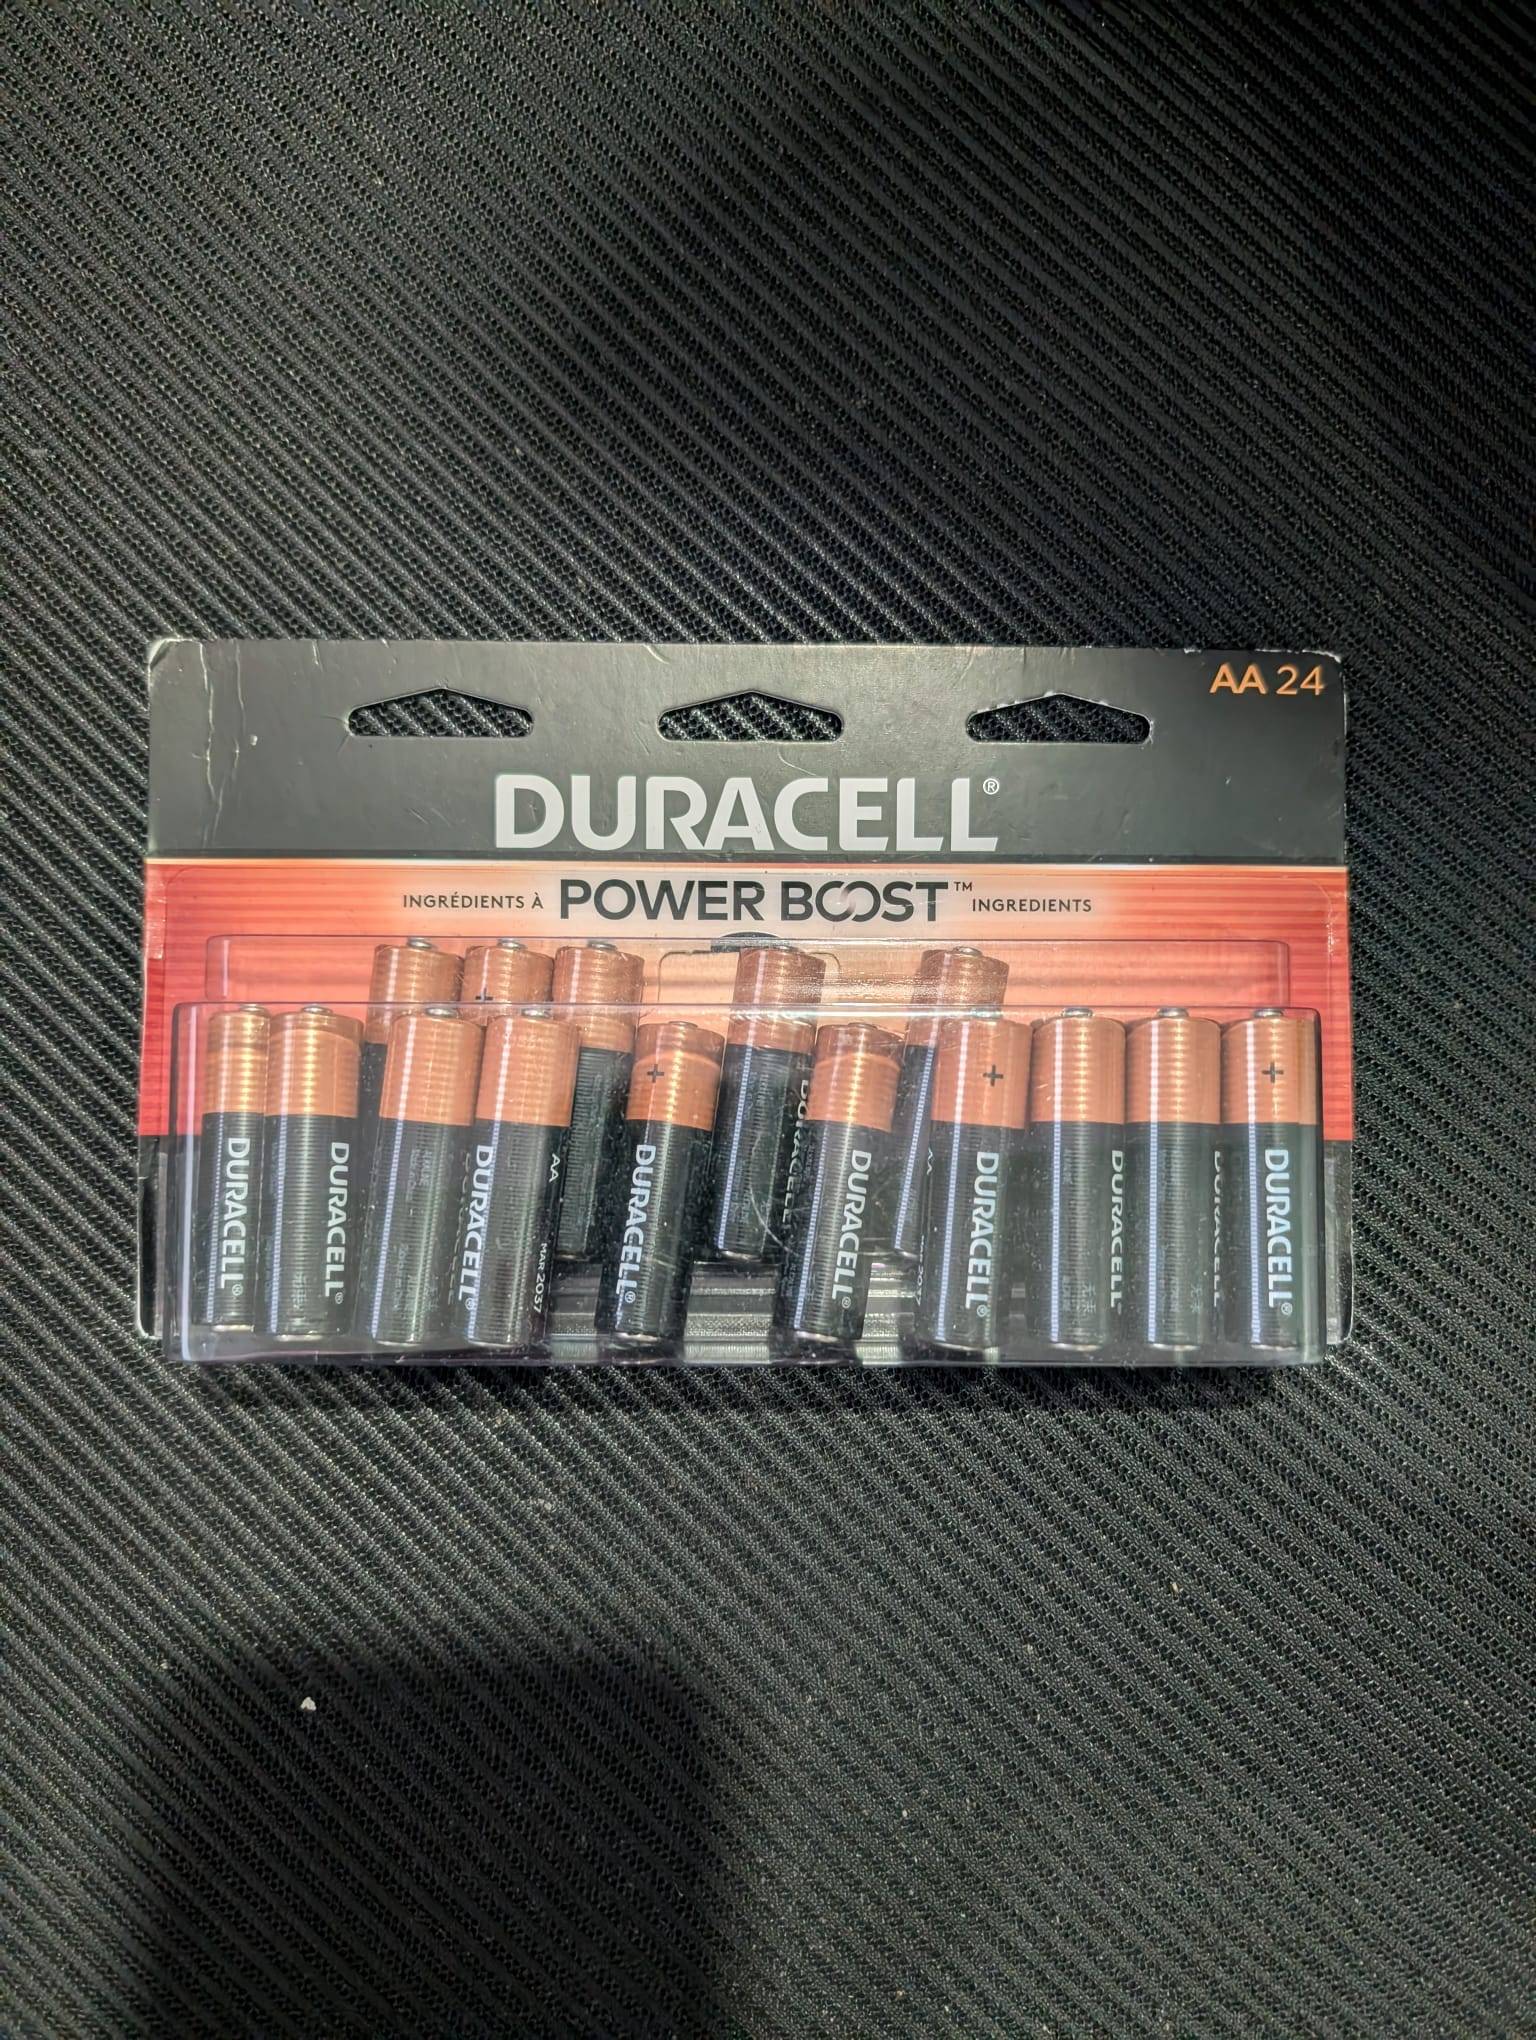
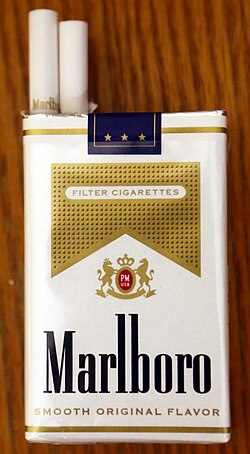
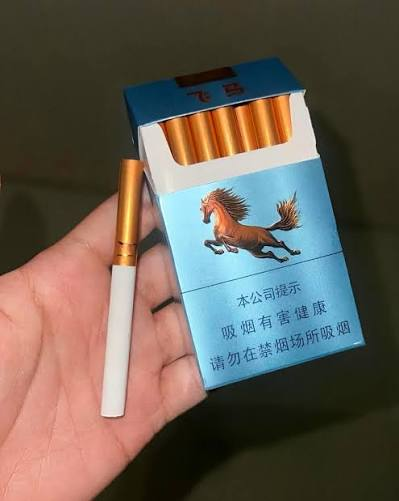

In [14]:
samples = ["data/testset/duracell_aa.jpg", "data/testset/marlboro.jpg", "data/testset/flyinghorse.jpg"]
render_grid(process(samples))

### Upload your own

Choose one or more photos; the grid renders after all are processed.

In [15]:
try:
    import ipywidgets as widgets
    from IPython.display import display, clear_output
    os.makedirs("data/uploads", exist_ok=True)
    uploader = widgets.FileUpload(accept="image/*", multiple=True)
    out = widgets.Output()

    def _on_upload(change):
        with out:
            clear_output()
            vals = uploader.value
            files = list(vals.values()) if isinstance(vals, dict) else list(vals)
            if not files:
                print("No files uploaded."); return
            paths = []
            for f in files:
                name = f.get("name") or f.get("metadata", {}).get("name", "upload.jpg")
                p = os.path.join("data/uploads", name)
                with open(p, "wb") as w:
                    w.write(bytes(f["content"]))
                paths.append(p)
            render_grid(process(paths))

    uploader.observe(_on_upload, names="value")
    print("Upload one or more product photos:")
    display(uploader, out)
except ImportError:
    print("ipywidgets not installed -> pip install ipywidgets")

Upload one or more product photos:


FileUpload(value=(), accept='image/*', description='Upload', multiple=True)

Output()

## Next steps for the demo

- **Real recognition:** `cp .env.example .env`, add `GEMINI_API_KEY` (free tier), then
  `set -a; source .env; set +a` and relaunch Jupyter.
- **Real products:** drop phone photos into `data/testset/` and add rows to `labels.csv`.
- Architecture: see `docs/final_report/figures/architecture_impl.png`.